# ECGResNet — Full Evaluation
### ROC Curves · Error Analysis · Confidence Distribution
**Model:** `ecg_resnet_best.pth` · Macro F1 = 0.860 · Dataset: MIT-BIH + INCART  
*Run with a clean kernel — no training required*

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_curve, auc
)
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#1c1c1e',
    'axes.facecolor':   '#2c2c2e',
    'axes.edgecolor':   '#3a3a3c',
    'axes.labelcolor':  '#8e8e93',
    'xtick.color':      '#636366',
    'ytick.color':      '#636366',
    'text.color':       '#f5f5f7',
    'grid.color':       '#3a3a3c',
    'grid.alpha':       0.5,
    'font.family':      'sans-serif',
    'figure.dpi':       130,
})
PALETTE = {'N': '#30d158', 'R': '#ffd60a', 'V': '#ff453a'}
print('Imports OK')

Imports OK


## 1 · Load Data & Model

In [2]:
# ── Data ───────────────────────────────────────────────────────────────────
X_test_raw = np.load('X_test_pi.npy')
y_test_raw = np.load('y_test_pi.npy')

le_old = LabelEncoder()
le_old.fit(['A', 'N', 'R', 'V'])
y_letters = le_old.inverse_transform(y_test_raw)

VALID  = {'N', 'V', 'R'}
mask   = np.array([l in VALID for l in y_letters])
X_test = X_test_raw[mask].astype(np.float32)
y_test = y_letters[mask]

le = LabelEncoder()
le.fit(['N', 'R', 'V'])
y_enc       = le.transform(y_test)
CLASS_NAMES = list(le.classes_)

# ── Normalisation ─────────────────────────────────────────────────────────
mu     = X_test.mean(axis=-1, keepdims=True)
std    = X_test.std(axis=-1,  keepdims=True) + 1e-8
X_test = (X_test - mu) / std

print(f'Test samples : {len(X_test):,}')
for c, n in sorted(Counter(y_test).items()):
    print(f'  {c} -> {n:>5} ({100*n/len(y_test):.1f}%)')

Test samples : 58,531
  N -> 48759 (83.3%)
  R ->  1345 (2.3%)
  V ->  8427 (14.4%)


In [3]:
# ── Model definition ──────────────────────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, channels, kernel_size=7):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=kernel_size//2),
            nn.BatchNorm1d(channels), nn.ReLU(),
            nn.Conv1d(channels, channels, kernel_size, padding=kernel_size//2),
            nn.BatchNorm1d(channels)
        )
        self.relu = nn.ReLU()
    def forward(self, x): return self.relu(x + self.conv(x))

class ECGResNet(nn.Module):
    def __init__(self, num_classes=3, in_channels=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2)
        )
        self.blocks = nn.Sequential(
            ResBlock(64), nn.MaxPool1d(2),
            ResBlock(64), nn.MaxPool1d(2),
            ResBlock(64)
        )
        self.pool       = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64, 128),
            nn.ReLU(), nn.Dropout(0.5), nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.pool(self.blocks(self.stem(x))))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = ECGResNet(num_classes=3, in_channels=2).to(device)
model.load_state_dict(torch.load('ecg_resnet_best.pth', map_location=device, weights_only=True))
model.eval()
print(f'Model loaded — device: {device}')
print(f'Parameters  : {sum(p.numel() for p in model.parameters()):,}')

Model loaded — device: cuda
Parameters  : 184,003


In [4]:
# ── Full inference ────────────────────────────────────────────────────────
X_t   = torch.tensor(X_test)
BATCH = 512
all_probs, all_preds = [], []

with torch.no_grad():
    for i in range(0, len(X_t), BATCH):
        xb    = X_t[i:i+BATCH].to(device)
        probs = torch.softmax(model(xb), dim=1).cpu().numpy()
        all_probs.append(probs)
        all_preds.append(probs.argmax(axis=1))

probs_all = np.concatenate(all_probs)
preds_all = np.concatenate(all_preds)
conf_all  = probs_all.max(axis=1)

macro_f1 = f1_score(y_enc, preds_all, average='macro')
acc      = (preds_all == y_enc).mean()
print(f'Accuracy  : {acc*100:.2f}%')
print(f'Macro F1  : {macro_f1:.4f}')

Accuracy  : 92.64%
Macro F1  : 0.8602


## 2 · Classification Report

In [5]:
print(classification_report(y_enc, preds_all, target_names=CLASS_NAMES, digits=4))

              precision    recall  f1-score   support

           N     0.9726    0.9396    0.9558     48759
           R     0.7567    0.9413    0.8390      1345
           V     0.7324    0.8476    0.7858      8427

    accuracy                         0.9264     58531
   macro avg     0.8206    0.9095    0.8602     58531
weighted avg     0.9331    0.9264    0.9287     58531



## 3 · Confusion Matrix

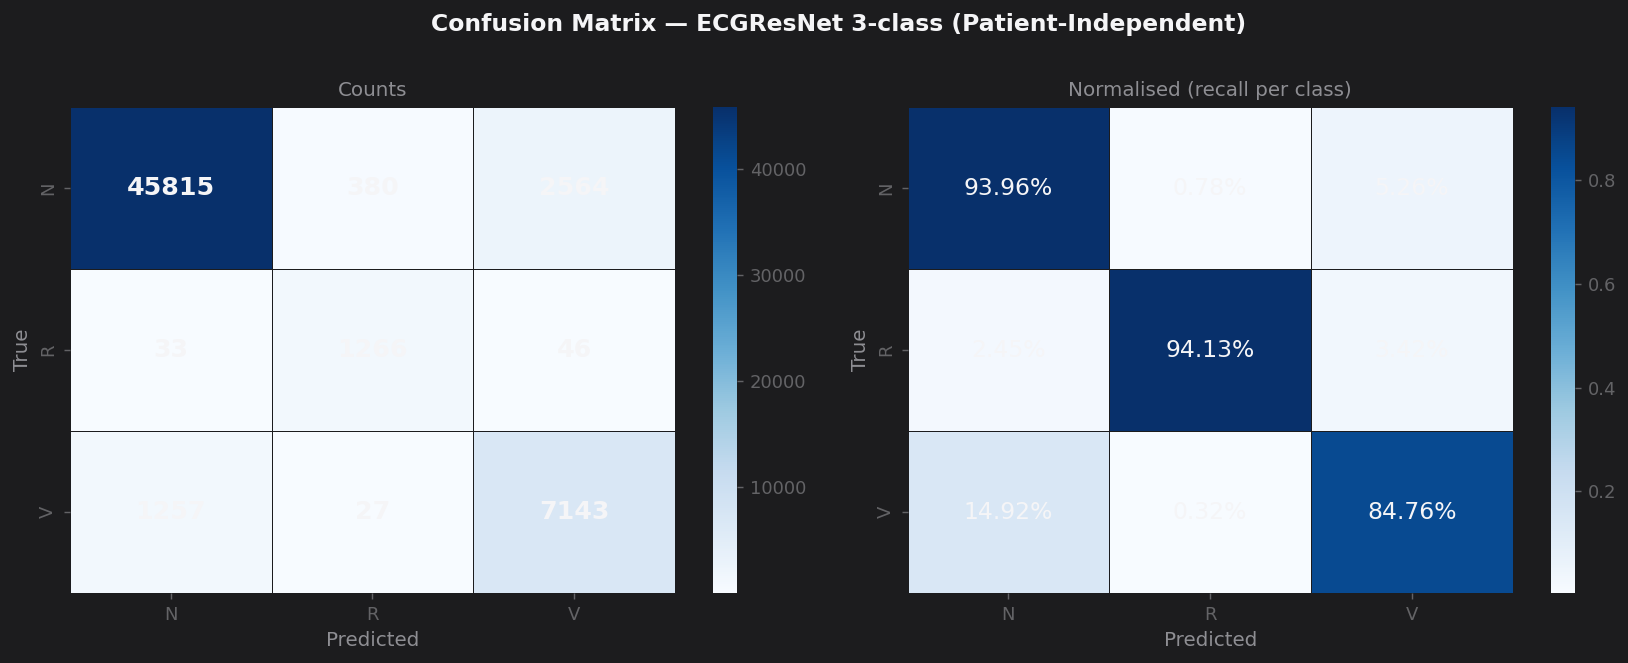

Saved: confusion_matrix_eval.png


In [6]:
cm = confusion_matrix(y_enc, preds_all)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrix — ECGResNet 3-class (Patient-Independent)',
             fontsize=13, fontweight='600', color='#f5f5f7', y=1.01)

# Counts
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', linewidths=.5, linecolor='#1c1c1e',
            annot_kws={'size': 14, 'weight': 'bold', 'color': '#f5f5f7'})
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('True', fontsize=11)
axes[0].set_title('Counts', fontsize=11, color='#8e8e93')

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', linewidths=.5, linecolor='#1c1c1e',
            annot_kws={'size': 13, 'color': '#f5f5f7'})
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('True', fontsize=11)
axes[1].set_title('Normalised (recall per class)', fontsize=11, color='#8e8e93')

plt.tight_layout()
plt.savefig('confusion_matrix_eval.png', dpi=150, bbox_inches='tight', facecolor='#1c1c1e')
plt.show()
print('Saved: confusion_matrix_eval.png')

## 4 · ROC Curves — One-vs-Rest

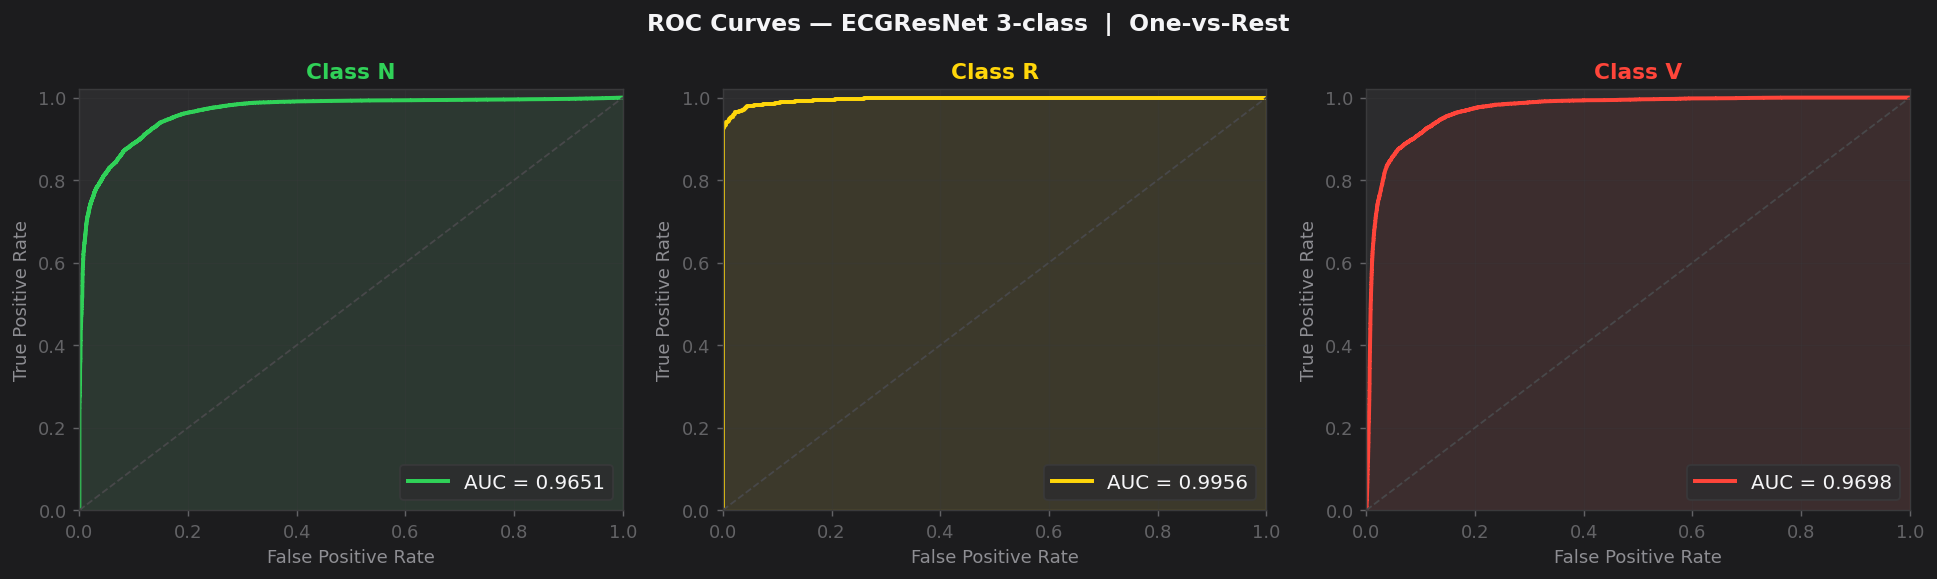


── AUC Scores ──
  N  AUC = 0.9651
  R  AUC = 0.9956
  V  AUC = 0.9698
  Macro AUC = 0.9769
Saved: roc_curves.png


In [7]:
y_bin = label_binarize(y_enc, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('ROC Curves — ECGResNet 3-class  |  One-vs-Rest',
             fontsize=13, fontweight='600', color='#f5f5f7')

auc_scores = {}
for i, (cls, color) in enumerate(PALETTE.items()):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs_all[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores[cls] = roc_auc

    ax = axes[i]
    ax.plot(fpr, tpr, color=color, lw=2.2, label=f'AUC = {roc_auc:.4f}')
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax.plot([0, 1], [0, 1], color='#48484a', lw=1, linestyle='--')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(f'Class {cls}', fontsize=12, fontweight='600', color=color)
    ax.legend(loc='lower right', fontsize=11,
              facecolor='#2c2c2e', edgecolor='#3a3a3c', labelcolor='#f5f5f7')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight', facecolor='#1c1c1e')
plt.show()

print('\n── AUC Scores ──')
for cls, score in auc_scores.items():
    print(f'  {cls}  AUC = {score:.4f}')
macro_auc = np.mean(list(auc_scores.values()))
print(f'  Macro AUC = {macro_auc:.4f}')
print('Saved: roc_curves.png')

## 5 · Confidence Distribution per Class

N  ->  median conf correct: 0.968  |  wrong: 0.572  |  errors: 2944
R  ->  median conf correct: 0.907  |  wrong: 0.557  |  errors: 79
V  ->  median conf correct: 0.860  |  wrong: 0.654  |  errors: 1284


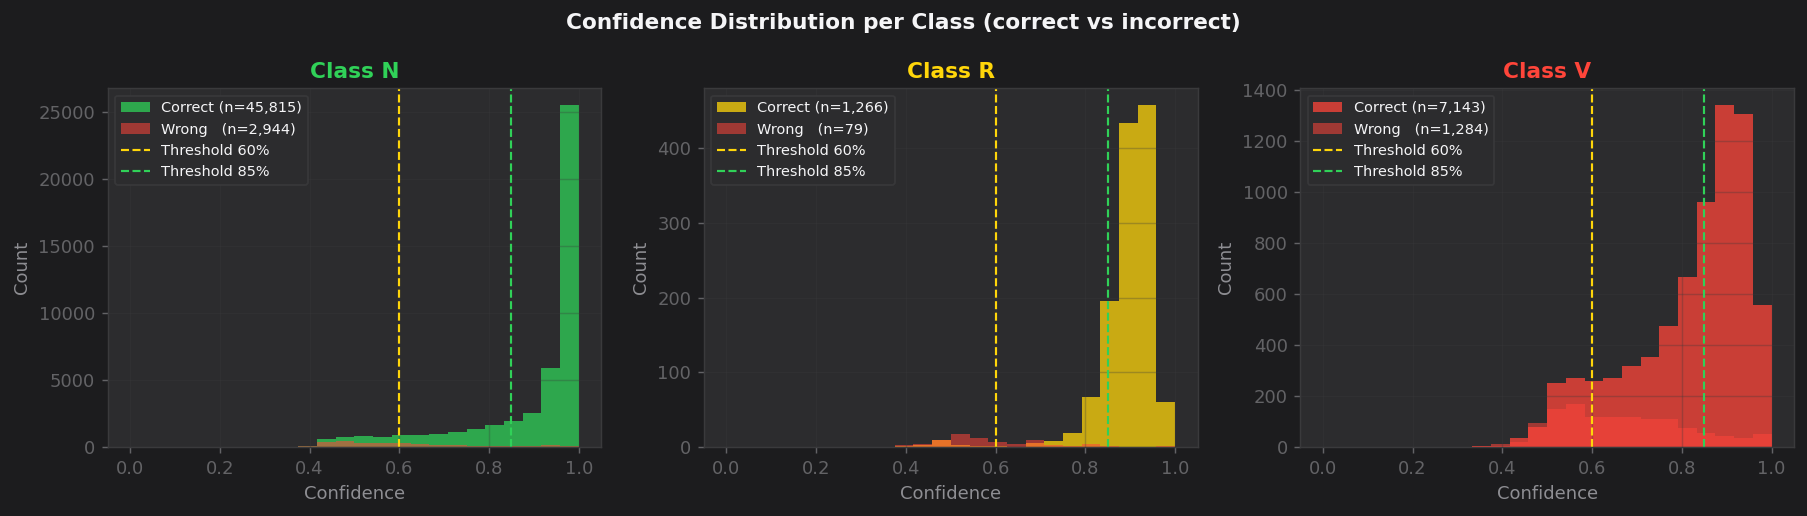

Saved: confidence_distribution.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Confidence Distribution per Class (correct vs incorrect)',
             fontsize=12, fontweight='600', color='#f5f5f7')

for i, (cls, color) in enumerate(PALETTE.items()):
    cls_idx = le.transform([cls])[0]
    mask_cls = (y_enc == cls_idx)
    correct  = conf_all[mask_cls & (preds_all == y_enc)]
    wrong    = conf_all[mask_cls & (preds_all != y_enc)]

    ax   = axes[i]
    bins = np.linspace(0, 1, 25)
    ax.hist(correct, bins=bins, color=color,     alpha=0.75, label=f'Correct (n={len(correct):,})')
    ax.hist(wrong,   bins=bins, color='#ff453a', alpha=0.55, label=f'Wrong   (n={len(wrong):,})')
    ax.axvline(0.60, color='#ffd60a', lw=1.2, linestyle='--', label='Threshold 60%')
    ax.axvline(0.85, color='#30d158', lw=1.2, linestyle='--', label='Threshold 85%')
    ax.set_title(f'Class {cls}', fontsize=12, fontweight='600', color=color)
    ax.set_xlabel('Confidence', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=8, facecolor='#2c2c2e', edgecolor='#3a3a3c', labelcolor='#f5f5f7')
    ax.grid(True, alpha=0.3)

    med_c = np.median(correct) if len(correct) else 0
    med_w = np.median(wrong)   if len(wrong)   else 0
    print(f'{cls}  ->  median conf correct: {med_c:.3f}  |  wrong: {med_w:.3f}  |  errors: {len(wrong)}')

plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight', facecolor='#1c1c1e')
plt.show()
print('Saved: confidence_distribution.png')

## 6 · Error Analysis — How does the model fail?

In [9]:
errors = preds_all != y_enc
print(f'Total errors : {errors.sum()} / {len(y_enc)} ({100*errors.mean():.2f}%)')
print()

true_err = le.inverse_transform(y_enc[errors])
pred_err = le.inverse_transform(preds_all[errors])
conf_err = conf_all[errors]

print('── Error breakdown (True -> Predicted) ──')
for t in CLASS_NAMES:
    for p in CLASS_NAMES:
        if t == p: continue
        mask = (true_err == t) & (pred_err == p)
        n    = mask.sum()
        if n == 0: continue
        med_cf = np.median(conf_err[mask])
        print(f'  {t} -> {p}  :  {n:>4} errors  |  median conf = {med_cf:.3f}')

print()
print('── High-confidence errors (conf >= 0.85) ──')
hc_err = errors & (conf_all >= 0.85)
print(f'  {hc_err.sum()} high-confidence errors ({100*hc_err.mean():.3f}% of total)')
if hc_err.sum() > 0:
    t_hc = le.inverse_transform(y_enc[hc_err])
    p_hc = le.inverse_transform(preds_all[hc_err])
    for t in CLASS_NAMES:
        for p in CLASS_NAMES:
            if t == p: continue
            n = ((t_hc == t) & (p_hc == p)).sum()
            if n: print(f'    {t} -> {p} : {n}')

Total errors : 4307 / 58531 (7.36%)

── Error breakdown (True -> Predicted) ──
  N -> R  :   380 errors  |  median conf = 0.501
  N -> V  :  2564 errors  |  median conf = 0.583
  R -> N  :    33 errors  |  median conf = 0.611
  R -> V  :    46 errors  |  median conf = 0.528
  V -> N  :  1257 errors  |  median conf = 0.658
  V -> R  :    27 errors  |  median conf = 0.490

── High-confidence errors (conf >= 0.85) ──
  539 high-confidence errors (0.921% of total)
    N -> R : 4
    N -> V : 372
    R -> N : 3
    V -> N : 160


## 7 · Executive Summary

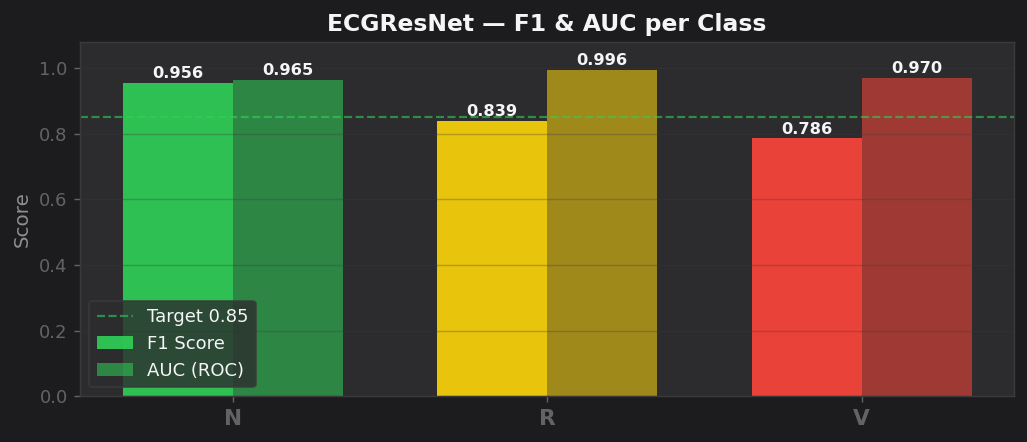


== FINAL RESULTS ==========================================
  Accuracy        : 92.64%
  Macro F1        : 0.8602
  Macro AUC       : 0.9769

  N  F1=0.9558  AUC=0.9651
  R  F1=0.8390  AUC=0.9956
  V  F1=0.7858  AUC=0.9698
Saved: summary_scores.png


In [10]:
per_cls_f1  = f1_score(y_enc, preds_all, average=None)
per_cls_auc = [auc_scores[c] for c in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(8, 3.5))
x  = np.arange(len(CLASS_NAMES))
w  = 0.35
b1 = ax.bar(x - w/2, per_cls_f1,  w, label='F1 Score',
            color=[PALETTE[c] for c in CLASS_NAMES], alpha=0.9)
b2 = ax.bar(x + w/2, per_cls_auc, w, label='AUC (ROC)',
            color=[PALETTE[c] for c in CLASS_NAMES], alpha=0.55)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + .005,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=9, color='#f5f5f7', fontweight='600')

ax.axhline(y=0.85, color='#30d158', lw=1.2, linestyle='--', alpha=0.6, label='Target 0.85')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=12, fontweight='600')
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('ECGResNet — F1 & AUC per Class', fontsize=13,
             fontweight='600', color='#f5f5f7')
ax.legend(facecolor='#2c2c2e', edgecolor='#3a3a3c', labelcolor='#f5f5f7', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('summary_scores.png', dpi=150, bbox_inches='tight', facecolor='#1c1c1e')
plt.show()

print('\n== FINAL RESULTS ==========================================')
print(f'  Accuracy        : {acc*100:.2f}%')
print(f'  Macro F1        : {macro_f1:.4f}')
print(f'  Macro AUC       : {macro_auc:.4f}')
print()
for c, f, a in zip(CLASS_NAMES, per_cls_f1, per_cls_auc):
    print(f'  {c}  F1={f:.4f}  AUC={a:.4f}')
print('===========================================================')
print('Saved: summary_scores.png')

## 8 · Threshold Tuning — Boost Macro F1 without retraining

Baseline Macro F1 : 0.8602
Best    Macro F1  : 0.8611  (+0.0009)
Best thresholds   : N=0.55  R=0.5  V=0.45

=== Classification Report — Threshold Tuned ===
              precision    recall  f1-score   support

           N     0.9748    0.9375    0.9558     48759
           R     0.7567    0.9413    0.8390      1345
           V     0.7277    0.8607    0.7886      8427

    accuracy                         0.9265     58531
   macro avg     0.8198    0.9131    0.8611     58531
weighted avg     0.9342    0.9265    0.9290     58531



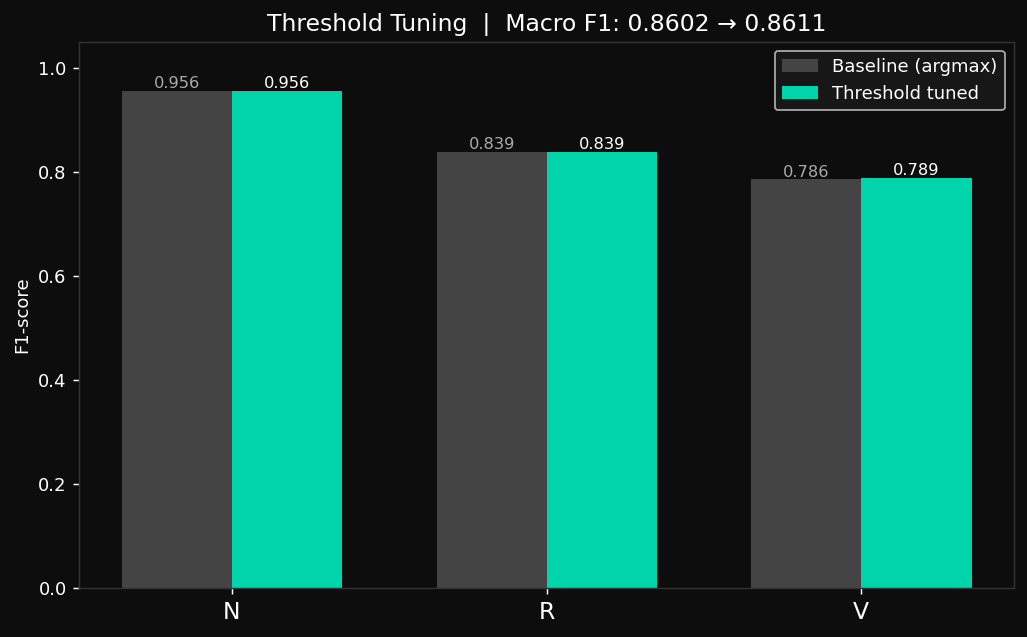

Saved: threshold_tuning.png


In [11]:
from itertools import product as iproduct

# ── Threshold application ─────────────────────────────────────────────────
def apply_thresholds(probs, thresholds):
    """
    For each sample, assign the class whose prob >= its threshold.
    If none pass or multiple pass → argmax fallback.
    thresholds : [t_N, t_R, t_V]
    """
    preds = np.empty(len(probs), dtype=int)
    for i, p in enumerate(probs):
        passing = [c for c in range(3) if p[c] >= thresholds[c]]
        preds[i] = passing[0] if len(passing) == 1 else int(np.argmax(p))
    return preds

# ── Grid search ───────────────────────────────────────────────────────────
# V has the most headroom → wider range; N is dominant → keep high
grid_N = [0.50, 0.55, 0.60, 0.65]
grid_R = [0.40, 0.45, 0.50]
grid_V = [0.30, 0.35, 0.40, 0.45]

baseline_f1 = f1_score(y_enc, preds_all, average='macro')
best_f1, best_thres = baseline_f1, [0.5, 0.5, 0.5]

for t_n, t_r, t_v in iproduct(grid_N, grid_R, grid_V):
    preds = apply_thresholds(probs_all, [t_n, t_r, t_v])
    mf1   = f1_score(y_enc, preds, average='macro')
    if mf1 > best_f1:
        best_f1, best_thres = mf1, [t_n, t_r, t_v]

print(f"Baseline Macro F1 : {baseline_f1:.4f}")
print(f"Best    Macro F1  : {best_f1:.4f}  (+{best_f1 - baseline_f1:.4f})")
print(f"Best thresholds   : N={best_thres[0]}  R={best_thres[1]}  V={best_thres[2]}")

# ── Full report with best thresholds ─────────────────────────────────────
best_preds = apply_thresholds(probs_all, best_thres)
print("\n=== Classification Report — Threshold Tuned ===")
print(classification_report(y_enc, best_preds, target_names=CLASS_NAMES, digits=4))

# ── Plot: Baseline vs Tuned F1 per class ─────────────────────────────────
f1_base  = f1_score(y_enc, preds_all,  average=None)
f1_tuned = f1_score(y_enc, best_preds, average=None)

x, width = np.arange(3), 0.35
fig, ax = plt.subplots(figsize=(8, 5), facecolor='#0d0d0d')
ax.set_facecolor('#0d0d0d')
ax.bar(x - width/2, f1_base,  width, label='Baseline (argmax)', color='#444')
ax.bar(x + width/2, f1_tuned, width, label='Threshold tuned',   color='#00d4aa')
for xi, (vb, vt) in enumerate(zip(f1_base, f1_tuned)):
    ax.text(xi - width/2, vb + 0.005, f'{vb:.3f}', ha='center', color='#aaa',  fontsize=9)
    ax.text(xi + width/2, vt + 0.005, f'{vt:.3f}', ha='center', color='white', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, color='white', fontsize=13)
ax.set_ylabel('F1-score', color='white')
ax.set_ylim(0, 1.05)
ax.set_title(
    f'Threshold Tuning  |  Macro F1: {baseline_f1:.4f} → {best_f1:.4f}',
    color='white', fontsize=13
)
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333')
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: threshold_tuning.png")
